# **Importing Necessary Libraries and Data**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from prophet import Prophet
import matplotlib.dates as mdates



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wallmart-sales-forecast-datasets/features.csv
/kaggle/input/wallmart-sales-forecast-datasets/stores.csv
/kaggle/input/wallmart-sales-forecast-datasets/train.csv
/kaggle/input/wallmart-sales-forecast-datasets/test.csv


In [2]:
df_store = pd.read_csv('/kaggle/input/wallmart-sales-forecast-datasets/stores.csv') #store data
df_train = pd.read_csv('/kaggle/input/wallmart-sales-forecast-datasets/train.csv') # train set
df_features = pd.read_csv('/kaggle/input/wallmart-sales-forecast-datasets/features.csv') #external information
df_test = pd.read_csv('/kaggle/input/wallmart-sales-forecast-datasets/test.csv') #test

# First Look to Data and Merging Dataframes

In [3]:
df_store.info()
df_train.info()
df_features.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        ---------

In [4]:
df_train['Date'] = pd.to_datetime(df_train['Date'])
df_test['Date'] = pd.to_datetime(df_test['Date'])
df_features['Date'] = pd.to_datetime(df_features['Date'])

df_train['Store'] = df_train['Store'].astype(int)
df_test['Store'] = df_test['Store'].astype(int)
df_features['Store'] = df_features['Store'].astype(int)
df_store['Store'] = df_store['Store'].astype(int)

In [5]:
# merging 4 different sets
df = df_train.merge(df_features, on=['Store', 'Date'], how='left')\
             .merge(df_store, on='Store', how='left')\
             .merge(df_test, on=['Store', 'Date', 'Dept'], how='left')
df.head(5)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size,IsHoliday
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315,NaN


In [6]:
df['IsHoliday_'] = df['IsHoliday_x'].combine_first(df['IsHoliday_y']).combine_first(df['IsHoliday'])
df.drop(columns=['IsHoliday_x', 'IsHoliday_y', 'IsHoliday'], inplace=True)
df.head(5)

/tmp/ipykernel_13/1717454381.py:1: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df['IsHoliday_'] = df['IsHoliday_x'].combine_first(df['IsHoliday_y']).combine_first(df['IsHoliday'])
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,IsHoliday_
0,1,1,2010-02-05,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,False
1,1,1,2010-02-12,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,True
2,1,1,2010-02-19,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,False
3,1,1,2010-02-26,19403.54,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,False
4,1,1,2010-03-05,21827.90,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,False


In [7]:
df.loc[df['Weekly_Sales']<=0]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,IsHoliday_
846,1,6,2012-08-10,-139.65,85.05,3.494,11436.22,245.0,6.85,6964.26,4836.22,221.958433,6.908,A,151315,False
2384,1,18,2012-05-04,-1.27,75.55,3.749,21290.13,NaN,69.89,4977.35,3261.04,221.671800,7.143,A,151315,False
6048,1,47,2010-02-19,-863.00,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,False
6049,1,47,2010-03-12,-698.00,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,A,151315,False
6051,1,47,2010-10-08,-58.00,63.93,2.633,NaN,NaN,NaN,NaN,NaN,211.746754,7.838,A,151315,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419597,45,80,2010-02-12,-0.43,27.73,2.773,NaN,NaN,NaN,NaN,NaN,181.982317,8.992,B,118221,True
419598,45,80,2010-02-19,-0.27,31.27,2.745,NaN,NaN,NaN,NaN,NaN,182.034782,8.992,B,118221,False
419603,45,80,2010-04-16,-1.61,54.28,2.899,NaN,NaN,NaN,NaN,NaN,181.692477,8.899,B,118221,False
419614,45,80,2010-07-02,-0.27,76.61,2.815,NaN,NaN,NaN,NaN,NaN,182.318780,8.743,B,118221,False


In [8]:
df = df.loc[df['Weekly_Sales'] > 0]
df.shape

(420212, 16)

In [9]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,420212.000000,420212.000000,420212,420212.000000,420212.000000,420212.000000,150181.000000,110904.000000,136651.000000,134518.000000,150929.000000,420212.000000,420212.000000,420212.000000
mean,22.195611,44.241309,2011-06-18 07:35:12.682169856,16033.114591,60.090599,3.360890,7247.821269,3330.146158,1441.736203,3384.782267,4629.531870,171.212496,7.960000,136749.732787
min,1.000000,1.000000,2010-02-05 00:00:00,0.010000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2120.130000,46.680000,2.933000,2240.270000,41.600000,5.100000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7661.700000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.350989,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20271.265000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.445487,8.567000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.787236,30.508819,NaN,22729.492116,18.447857,0.458519,8293.028741,9460.395025,9631.968459,6295.136952,5960.171711,39.162445,1.863879,60993.084568


In [10]:
#weekly ave sales 
storemean=df.groupby(by='Store').mean(numeric_only=True)
storemean.head(3)

,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,IsHoliday_
Store,,,,,,,,,,,,,
1,44.391844,21749.145978,68.229523,3.218529,8084.136978,2969.254088,1247.632927,3755.782433,5030.423671,215.994144,7.610824,151315.0,0.070702
2,44.463188,26961.734433,68.112759,3.220177,10664.454989,5305.464264,1736.961468,4760.093530,6550.234217,215.653301,7.623117,202307.0,0.070491
3,41.024706,6380.226664,71.291182,3.218982,3078.679627,1072.600101,930.424791,922.368559,1268.459747,219.400772,7.175933,37392.0,0.070131


# Exploratory Data Analysis (EDA)

In [11]:
colors = ['#FEB59A', '#CE3E12', '#7B6C28', '#4F6D7A', '#C0D6DF']

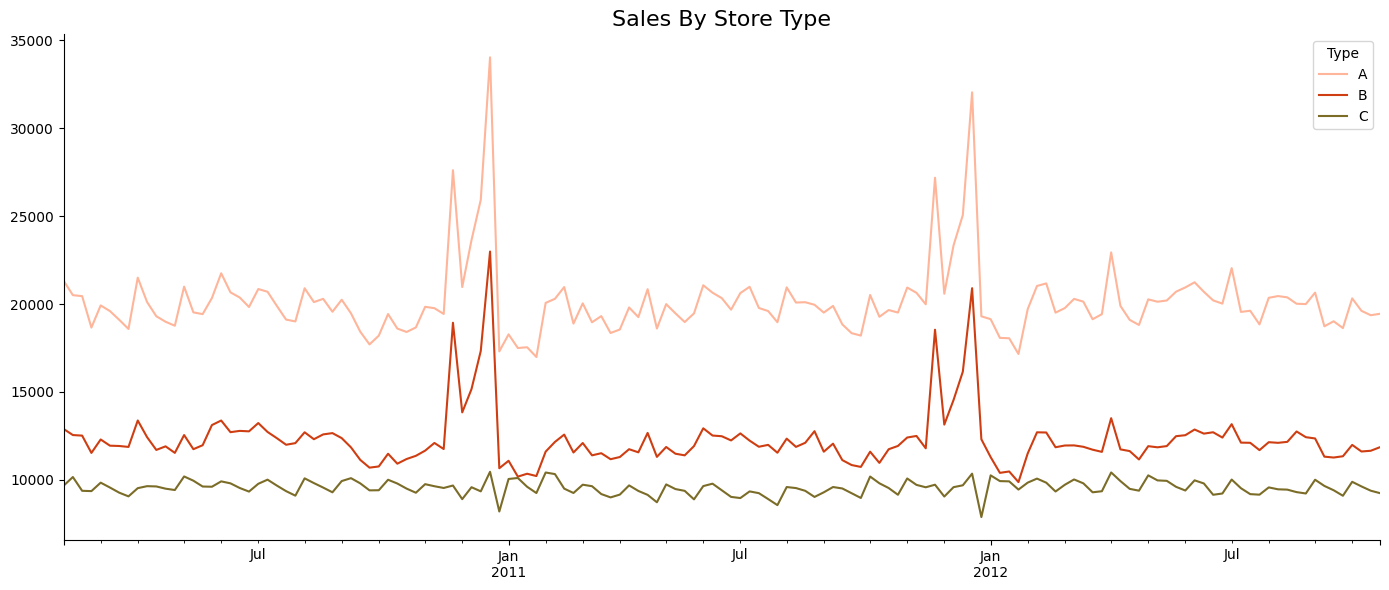

In [12]:
monthly_sales_by_storetype = pd.pivot_table(df, values="Weekly_Sales", columns="Type", index="Date")

monthly_sales_by_storetype.plot(color=colors, figsize=(14, 6)) 
plt.title("Sales By Store Type", fontsize=16)
plt.ylabel("")
plt.xlabel("")
sns.despine()  
plt.tight_layout()
plt.show()

**Findings:** 

* Clear seasonality around holidays (notably Thanksgiving and Christmas)
* Store Type A consistently outperformed B and C in sales
* Store size correlates with type, affecting capacity and reach

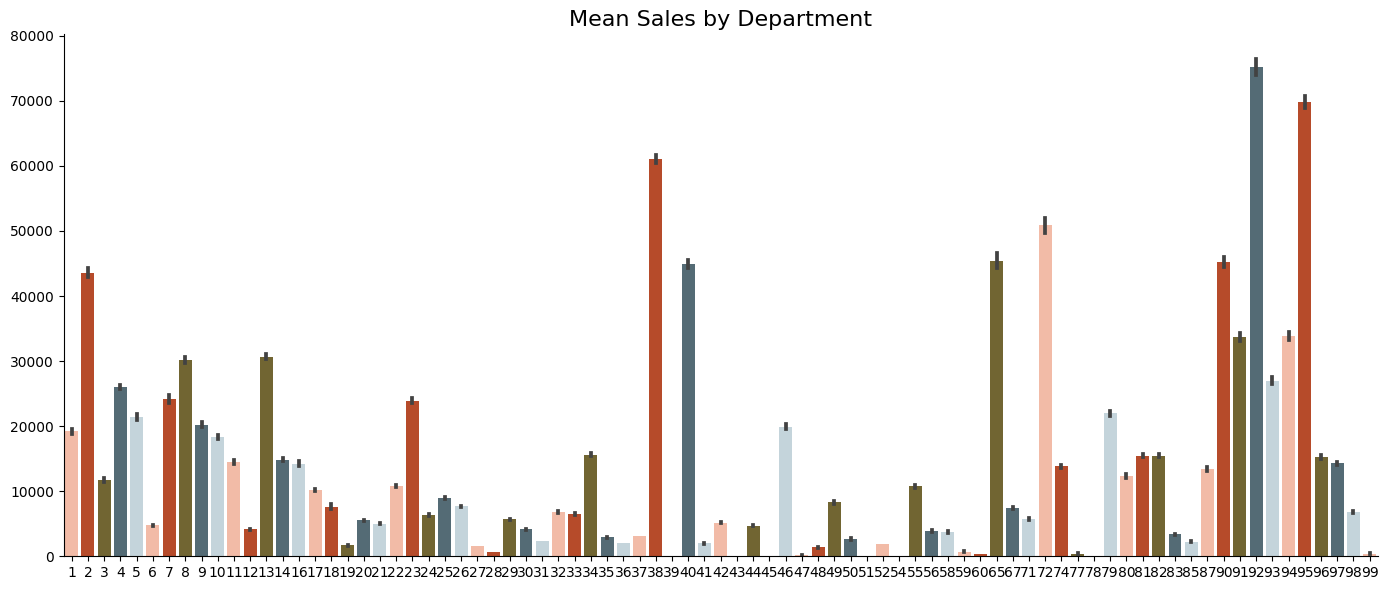

In [13]:
plt.figure(figsize=(14, 6)) 

df_clean = df.dropna(subset=['Weekly_Sales', 'Dept'])
sns.barplot(x="Dept", y="Weekly_Sales", data=df_clean, palette=colors, estimator='mean')

plt.ylabel("")
plt.xlabel("")
sns.despine()  
plt.title('Mean Sales by Department', fontsize=16)
plt.tight_layout()
plt.show()

**Findings:**

* Certain departments (e.g., electronics, groceries) generate higher sales
* Opportunities to optimize underperforming departments

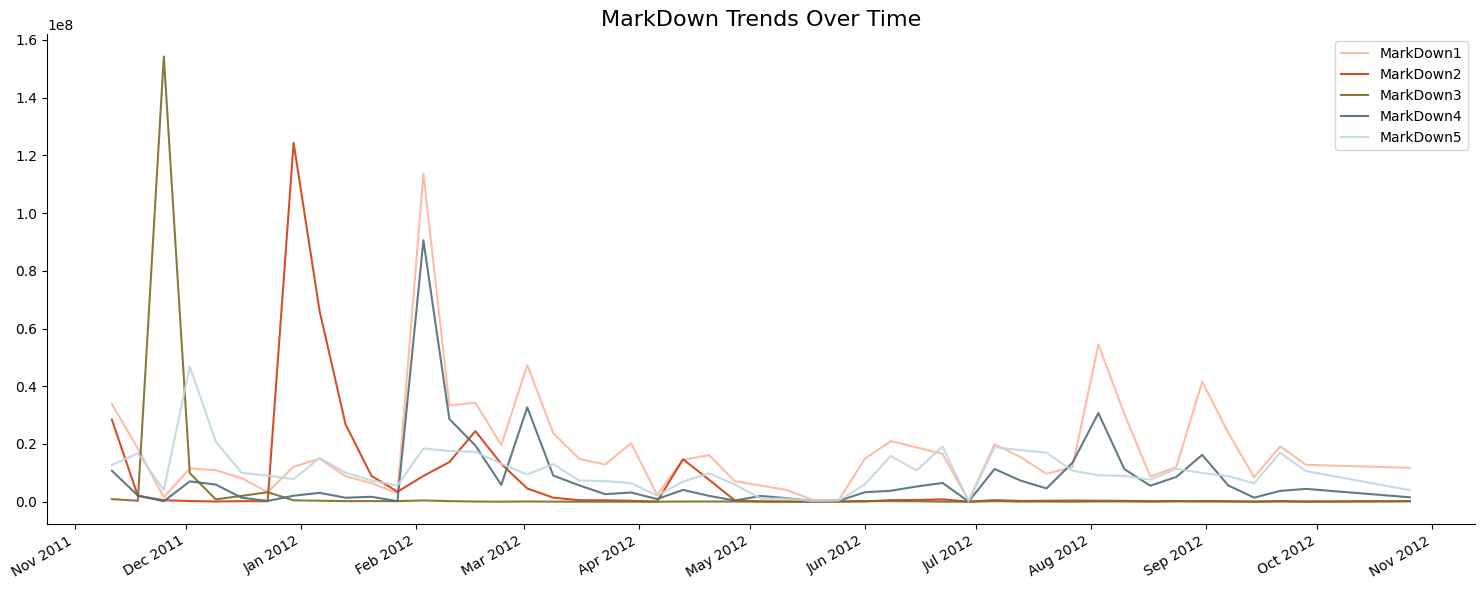

In [14]:
markdown_by_date = df[['Date', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].copy()
markdown_by_date = markdown_by_date.dropna().groupby('Date').sum()


markdown_by_date.plot(color=colors, figsize=(15,6), alpha=0.9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))  
plt.title("MarkDown Trends Over Time", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

**Findings:**

* Spikes in markdowns are often followed by increases in sales
* Suggests markdowns are used strategically around sales events and holidays

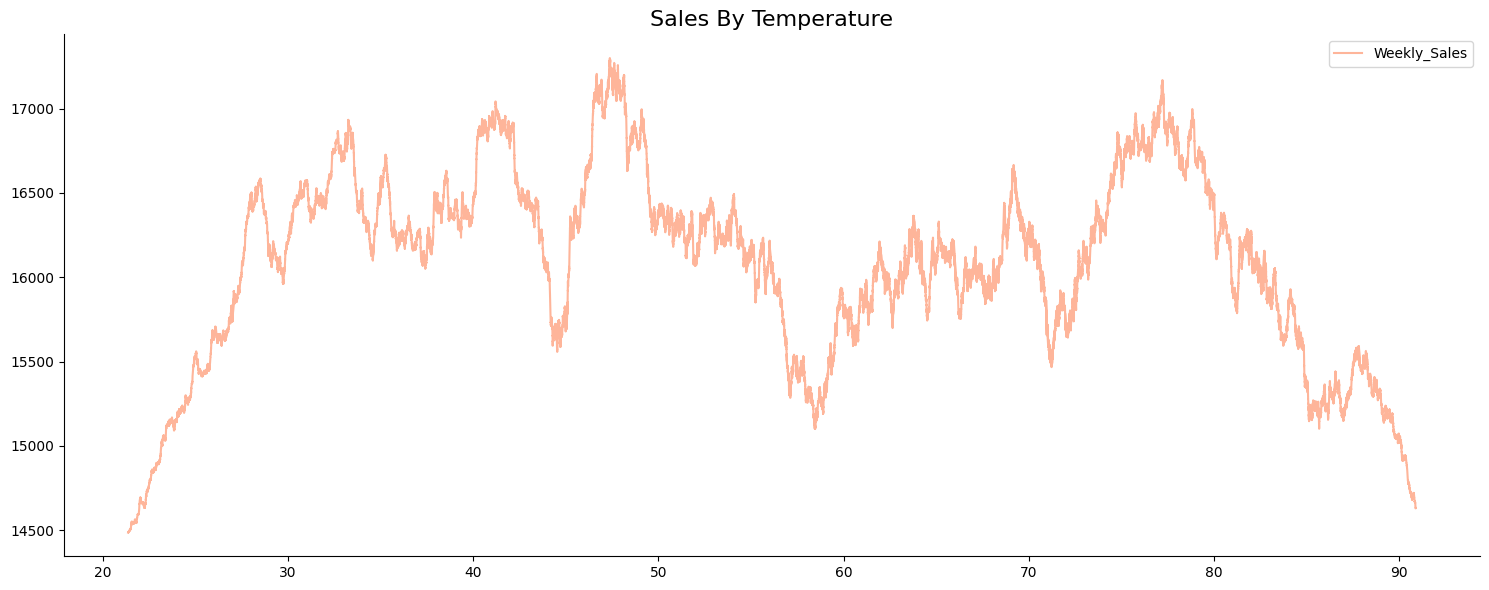

In [15]:
df_temp = df[['Temperature', 'Weekly_Sales']].copy()

df_temp = df_temp.sort_values(by='Temperature')

df_temp_rolled = df_temp.rolling(window=20000).mean()

# Шаг 4: строим график
df_temp_rolled.plot(x='Temperature', y='Weekly_Sales', color=colors, figsize=(15,6))
plt.title("Sales By Temperature", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.grid(False)
sns.despine()  
plt.tight_layout()
plt.show()

**Findings:**

* Mild temperatures (around 40–50°F and 70–80°F) are associated with higher weekly sales, suggesting that moderate weather encourages more in-store shopping and holidays
* Extremely cold or hot temperatures (below 30°F or above 85°F) often coincide with reduced sales, possibly due to customers avoiding travel or adverse weather conditions

/tmp/ipykernel_13/3914157338.py:22: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(data=smoothed, x='Date', y='CPI', hue='Type', palette=colors, linewidth=2, alpha=0.6)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to si

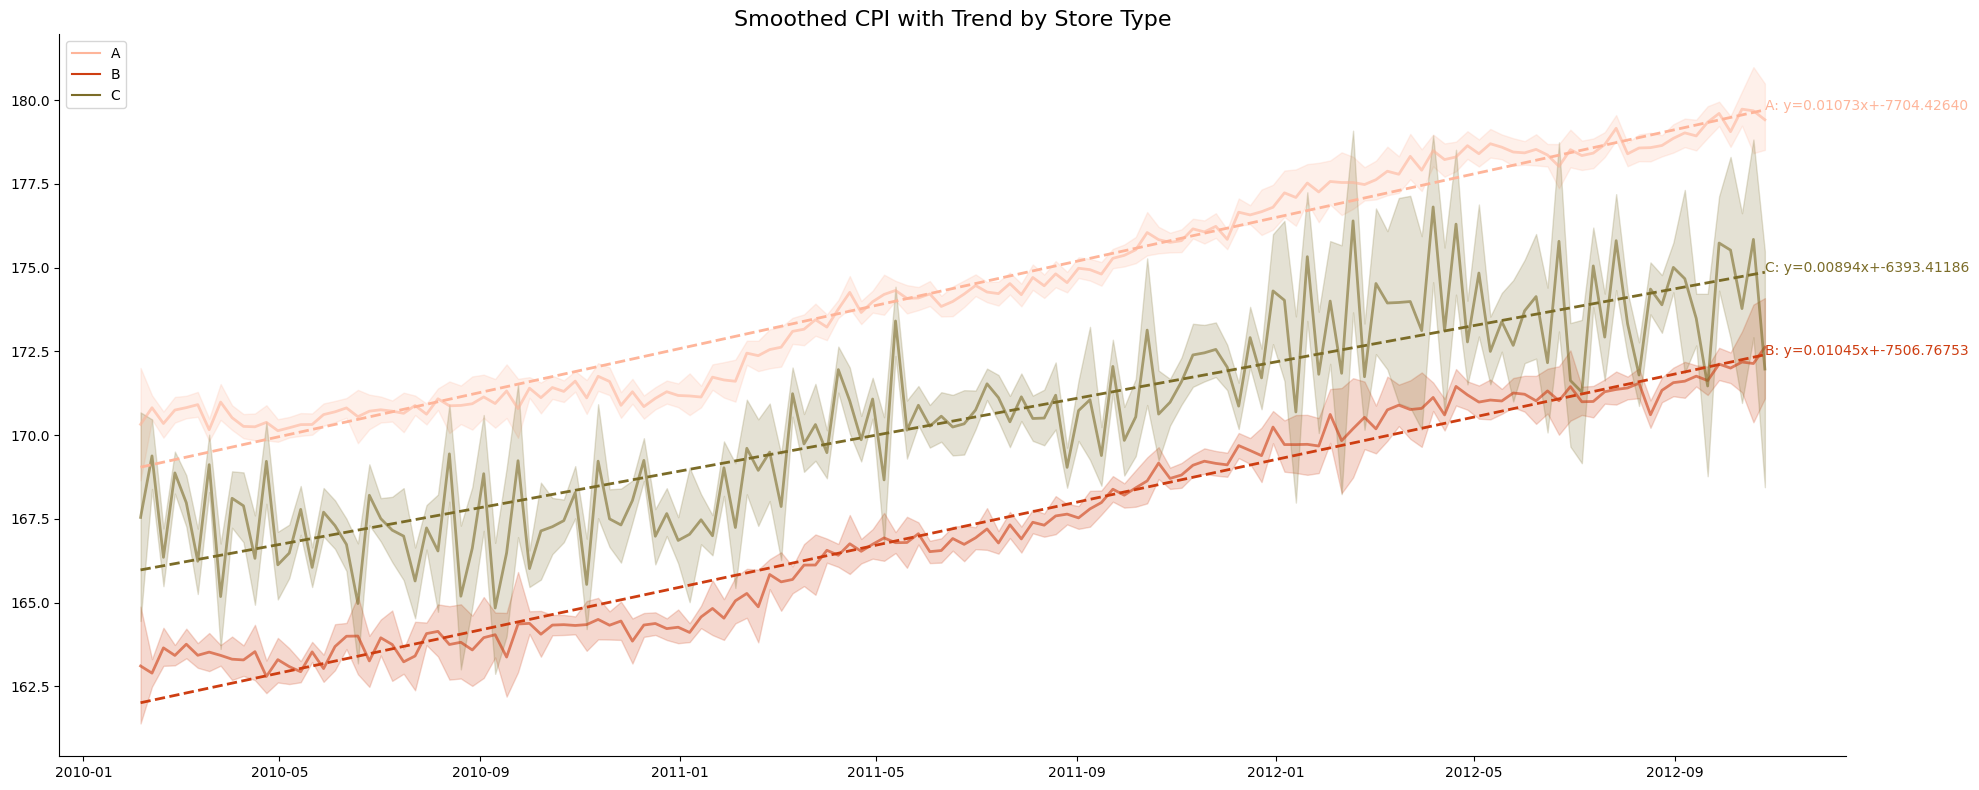

In [16]:
# Подготовка данных
df_temp = df[['CPI', 'Date', 'Type']].dropna()
df_temp['Date'] = pd.to_datetime(df_temp['Date'])
df_temp = df_temp.sort_values(by='Date')
df_temp.set_index('Date', inplace=True)


smoothed = pd.DataFrame()

for t in df_temp['Type'].unique():
    group = df_temp[df_temp['Type'] == t]
    numeric = group[['CPI']].rolling(window=30, min_periods=1).mean()
    numeric['Type'] = t
    smoothed = pd.concat([smoothed, numeric])


smoothed = smoothed.reset_index()


plt.figure(figsize=(20,8))

sns.lineplot(data=smoothed, x='Date', y='CPI', hue='Type', palette=colors, linewidth=2, alpha=0.6)

for t, color in zip(smoothed['Type'].unique(), colors):
    subset = smoothed[smoothed['Type'] == t].dropna()
    
    X = subset['Date'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    y = subset['CPI'].values

    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    k = model.coef_[0]
    b = model.intercept_

    plt.plot(subset['Date'], y_pred, '--', color=color, linewidth=2)


    x_pos = subset['Date'].iloc[-1]
    y_pos = y_pred[-1]
    plt.text(x_pos, y_pos, f'{t}: y={k:.5f}x+{b:.5f}', fontsize=10, color=color)

plt.title("Smoothed CPI with Trend by Store Type", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.grid(False)
plt.legend(loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

**Findings:**

* The overall CPI trend is similar across store types, indicating that inflation and economic factors impact all store categories in comparable ways
* For Store Types A and B, there is a clear positive trend — the Consumer Price Index gradually increases over time, suggesting these store types are more sensitive to economic changes
* In contrast, Store Type C shows a less pronounced or nearly flat trend, possibly reflecting more stable conditions, differences in store size, or departmental composition within this type

/tmp/ipykernel_13/380962365.py:20: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(data=smoothed, x='Date', y='Unemployment', hue='Type', palette=colors, linewidth=2, alpha=0.6)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `nam

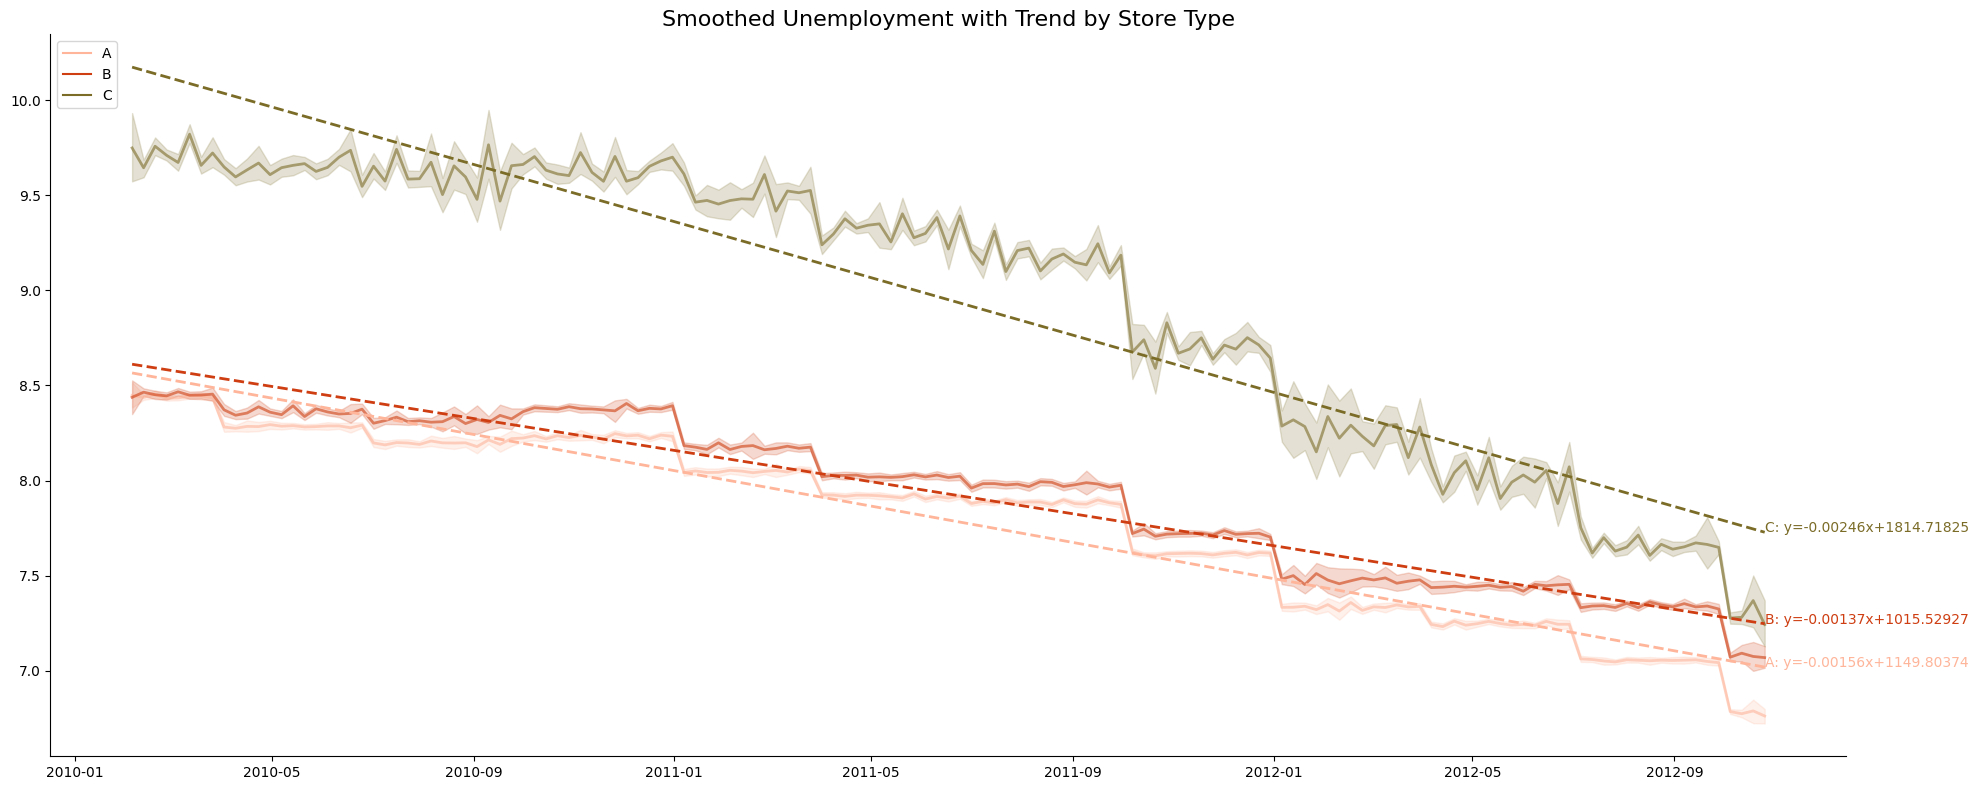

In [17]:

df_temp = df[['Unemployment', 'Date', 'Type']].dropna()
df_temp['Date'] = pd.to_datetime(df_temp['Date'])
df_temp = df_temp.sort_values(by='Date')
df_temp.set_index('Date', inplace=True)

smoothed = pd.DataFrame()

for t in df_temp['Type'].unique():
    group = df_temp[df_temp['Type'] == t]
    numeric = group[['Unemployment']].rolling(window=30, min_periods=1).mean()
    numeric['Type'] = t
    smoothed = pd.concat([smoothed, numeric])


smoothed = smoothed.reset_index()


plt.figure(figsize=(20,8))

sns.lineplot(data=smoothed, x='Date', y='Unemployment', hue='Type', palette=colors, linewidth=2, alpha=0.6)

for t, color in zip(smoothed['Type'].unique(), colors):
    subset = smoothed[smoothed['Type'] == t].dropna()
    
    
    X = subset['Date'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    y = subset['Unemployment'].values

    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    k = model.coef_[0]
    b = model.intercept_

    plt.plot(subset['Date'], y_pred, '--', color=color, linewidth=2)

    x_pos = subset['Date'].iloc[-1]
    y_pos = y_pred[-1]
    plt.text(x_pos, y_pos, f'{t}: y={k:.5f}x+{b:.5f}', fontsize=10, color=color)

plt.title("Smoothed Unemployment with Trend by Store Type", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.grid(False)
plt.legend(loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

**Findings:**

* Overall, the unemployment rate fluctuates but exhibits clear differences in trends across store types, generally showing a downward trend
* Store Types A and B display a nearly flat yet slightly downward trend, indicating relatively stable and improving unemployment conditions for these segments
* In contrast, Store Type C shows a pronounced downward trend, possibly reflecting stronger improvements in local employment conditions for this category

13:25:52 - cmdstanpy - INFO - Chain [1] start processing
13:25:52 - cmdstanpy - INFO - Chain [1] done processing


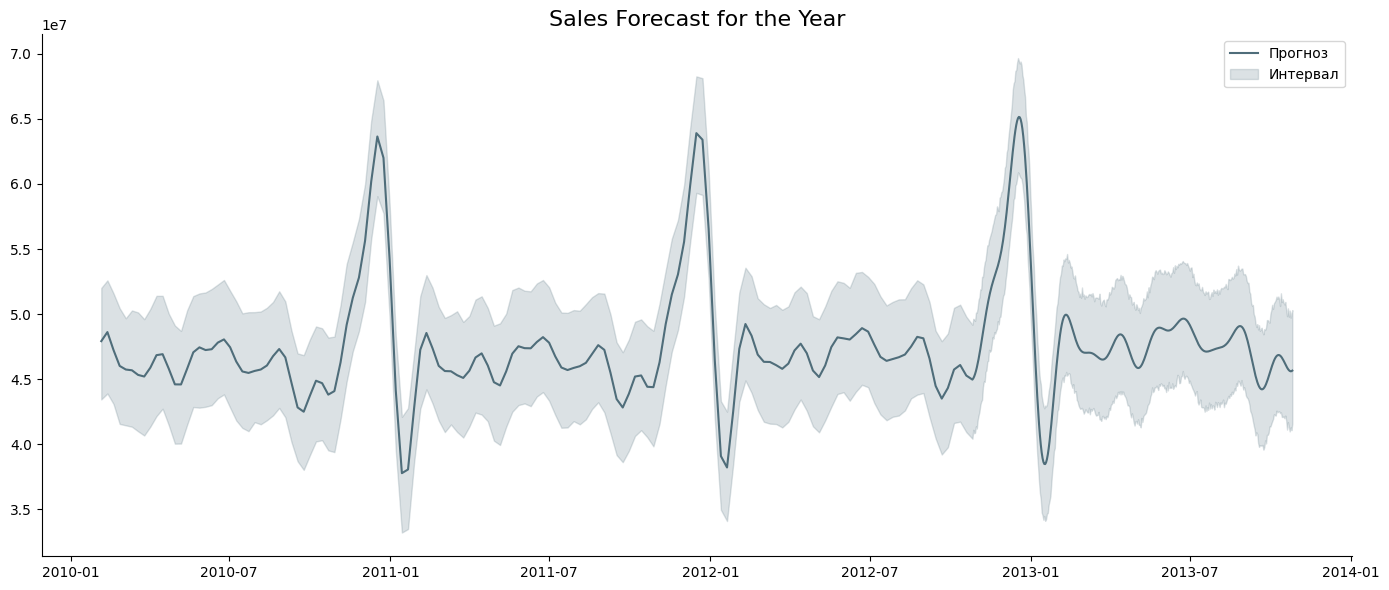

In [18]:
df_prophet = df[['Date', 'Weekly_Sales']].copy()
df_prophet = df_prophet.groupby('Date').sum().reset_index()
df_prophet.columns = ['ds', 'y']


model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)


plt.figure(figsize=(14, 6))
main_color = "#4F6D7A"  

plt.plot(forecast['ds'], forecast['yhat'], color=main_color, label='Прогноз')

plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                 color=main_color, alpha=0.2, label='Интервал')


plt.title("Sales Forecast for the Year", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.grid(False)
sns.despine()
plt.legend()
plt.tight_layout()
plt.show()

**Findings**

* The Prophet model effectively forecasts total weekly sales for the upcoming year (365 days), capturing seasonal patterns and trends from historical data
* The forecast shows distinct seasonal peaks likely corresponding to holiday periods and sales events (e.g., Christmas, Black Friday)